# BYU CS 473 — KL Divergence

In this assignment, you will learn the basics of **Kullback–Leibler (KL) divergence**.  
KL divergence measures how one probability distribution differs from another.

---

## Learning Goals
- Understand the definition of KL divergence  
- Compute KL divergence between two Gaussian distributions  
- Understand why KL divergence is always non-negative  
- Relate KL divergence to Maximum Likelihood Estimation (MLE)  
- Compare forward vs reverse KL divergence


## 1. Definition

For discrete distributions:

\[
D_{\text{KL}}(P \,\|\, Q) = \sum_x P(x) \log \frac{P(x)}{Q(x)}
\]

For continuous distributions:

\[
D_{\text{KL}}(P \,\|\, Q) = \int p(x) \log \frac{p(x)}{q(x)} dx
\]

- KL divergence is **not symmetric**: \( D_{\text{KL}}(P \,\|\, Q) \neq D_{\text{KL}}(Q \,\|\, P) \)  
- KL divergence is **not a distance metric**, but it measures how well \(Q\) approximates \(P\).  


### Exercise 1
In your own words, explain what KL divergence measures.  
Give a real-world analogy (e.g., communication, language modeling).


Your response here

## 2. Example: KL Divergence Between Two Gaussians

If \( P = \mathcal{N}(\mu_p, \sigma_p^2) \) and \( Q = \mathcal{N}(\mu_q, \sigma_q^2) \), the KL divergence is:

\[
D_{\text{KL}}(P \,\|\, Q) = \log \frac{\sigma_q}{\sigma_p}
+ \frac{\sigma_p^2 + (\mu_p - \mu_q)^2}{2\sigma_q^2} - \frac{1}{2}
\]


In [ ]:
import numpy as np

def kl_gaussian(mu_p, sigma_p, mu_q, sigma_q):
    return np.log(sigma_q/sigma_p) + (sigma_p**2 + (mu_p - mu_q)**2)/(2*sigma_q**2) - 0.5

# Example
print("KL(P||Q) with mu_p=0, sigma_p=1, mu_q=1, sigma_q=2:")
kl_gaussian(0, 1, 1, 2)




KL(P||Q) with mu_p=0, sigma_p=1, mu_q=1, sigma_q=2:


np.float64(0.4431471805599453)

### Exercise 2
- Compute KL(P‖Q) for several pairs of Gaussian distributions.  
- Which matters more: differences in mean, or differences in variance?  
- Plot KL(P‖Q) as μ_q varies from -3 to 3, holding σ fixed.


In [ ]:
# Your code here

## 3. Non-Negativity of KL Divergence

**Gibbs’ Inequality**:  
\[
D_{\text{KL}}(P \,\|\, Q) \geq 0
\]

with equality if and only if \(P = Q\).  
This means the "distance" is never negative.

Intuition: if you approximate \(P\) with \(Q\), you can never do better than the true distribution.


In [ ]:
# Quick numerical experiment
p = np.array([0.4, 0.6])
q = np.array([0.5, 0.5])
kl = np.sum(p * np.log(p/q))
kl


np.float64(0.020135513550688863)

### Exercise 3
- Construct two different discrete distributions P and Q.  
- Compute KL(P‖Q) and KL(Q‖P).  
- Verify that both are ≥ 0.  
- When do you get KL = 0?


In [ ]:
# Your code here

## 4. KL Divergence and Maximum Likelihood Estimation

Suppose data is generated from distribution P, and we fit model Qθ.  

- MLE maximizes likelihood:  
  \[
  \theta^* = \arg \max_\theta \sum \log q_\theta(x_i)
  \]
- Equivalent to minimizing:  
  \[
  D_{\text{KL}}(P \,\|\, Q_\theta)
  \]

Thus, **MLE is KL minimization**: we make our model Qθ as close as possible to the true distribution P.


### Exercise 4
Explain in your own words:
- Why minimizing KL(P‖Q) is the same as maximizing likelihood.  
- Why this interpretation helps us understand model training.


Your response here

## 5. Forward vs Reverse KL

- **Forward KL:** \(D_{\text{KL}}(P \,\|\, Q)\)  
  - Penalizes missing modes (Q must cover all support of P).  
  - "Mode covering."

- **Reverse KL:** \(D_{\text{KL}}(Q \,\|\, P)\)  
  - Penalizes putting mass where P has none.  
  - "Mode seeking."

This asymmetry explains why different algorithms (e.g. variational inference vs expectation propagation) behave differently.


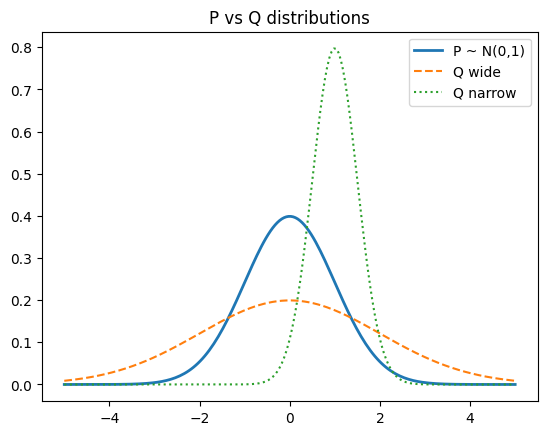

In [ ]:
import matplotlib.pyplot as plt
import scipy.stats as stats

x = np.linspace(-5, 5, 200)
p = stats.norm(0, 1).pdf(x)   # true distribution
q1 = stats.norm(0, 2).pdf(x)  # wide Q
q2 = stats.norm(1, 0.5).pdf(x) # narrow Q

plt.plot(x, p, label="P ~ N(0,1)", linewidth=2)
plt.plot(x, q1, label="Q wide", linestyle="--")
plt.plot(x, q2, label="Q narrow", linestyle=":")
plt.legend()
plt.title("P vs Q distributions")
plt.show()


### Exercise 5
1. Compute both KL(P‖Q) and KL(Q‖P) for P=N(0,1), Q=N(1,0.5).  
2. Which is larger? Why?  
3. In which case would forward KL be more appropriate? Reverse KL?


In [ ]:
# Your code here

## 6. Reflection

### Exercise 6
Answer in 2–3 sentences each:

1. Why is KL divergence always non-negative?  
2. How does KL divergence connect to MLE?  
3. Why do forward and reverse KL behave differently?  


Your response here